In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

# Reading chains

In [36]:
blind = False
#fname_blind = '../output/some-sims-dv-cosmogrid/des-y3-2pt-blind-metacal-simcov.txt'

sim1 = utils.read_cosmosis_mcmc_des_chain('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim1.txt', to_mcsamples=True, blind=blind)
sim2 = utils.read_cosmosis_mcmc_des_chain('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim2.txt', to_mcsamples=True, blind=blind)
sim3 = utils.read_cosmosis_mcmc_des_chain('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim3.txt', to_mcsamples=True, blind=blind)

all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)
map3_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-map3-all.txt', to_mcsamples=True, blind=blind)
twpt_all_sims = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-500simcov.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


## 2pt, map3 and joint

<Figure size 600x600 with 0 Axes>

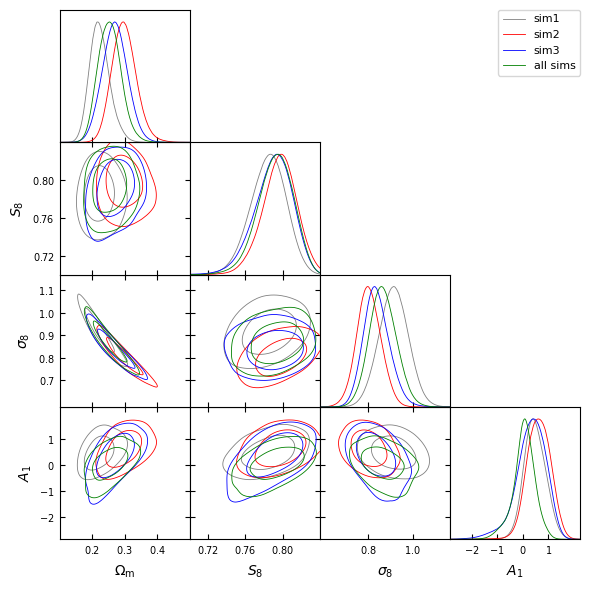

In [4]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([sim1, sim2, sim3, all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['sim1', 'sim2',  'sim3', 'all sims'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'blue', 'green'])
plt.show()

<Figure size 600x600 with 0 Axes>

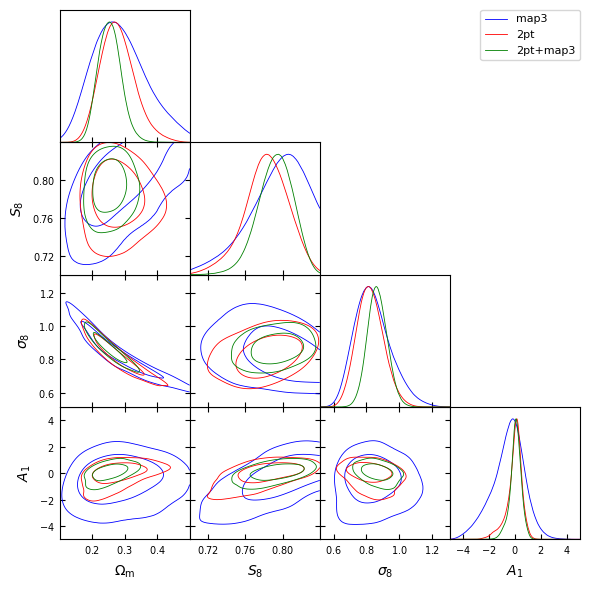

In [5]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([map3_all_sims, twpt_all_sims, all_sims], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['map3', '2pt', '2pt+map3'], legend_loc='upper right', 
    contour_colors=['blue', 'red', 'green'])
plt.show()

In [24]:
import numpy as np

# Load the MCMC samples from your file
# Assuming your file is a space-separated text file with columns corresponding to parameters and log-posterior
data1 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim1.txt')
data2 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim2.txt')
data3 = np.loadtxt('../output/some-sims-dv-cosmogrid/des-y3-2pt-map3-all-sim3.txt')

data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-map3-all.txt')
map3_data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-map3-all.txt')
twpt_data_all = np.loadtxt('../output/test-cosmogridc-joint-2pt-moped-run-weighted/des-y3-2pt-500simcov.txt')

log_posterior = twpt_data_all[:, -2]
parameters = twpt_data_all[:, :-2]

# Find the index of the sample with the highest log-posterior
best_fit_index = np.argmax(log_posterior)
best_fit_params = parameters[best_fit_index]

print("Best-fit parameters:")
for i, param_value in enumerate(best_fit_params):
    print(f"Parameter {i}: {param_value:.5f}")

Best-fit parameters:
Parameter 0: 0.28477
Parameter 1: 0.62730
Parameter 2: 0.05014
Parameter 3: 1.00510
Parameter 4: 0.78524
Parameter 5: 0.30273
Parameter 6: -0.00725
Parameter 7: -0.01809
Parameter 8: -0.02406
Parameter 9: -0.03414
Parameter 10: -0.00690
Parameter 11: -0.00349
Parameter 12: -0.00189
Parameter 13: -0.00391
Parameter 14: 0.02171
Parameter 15: -2.02993
Parameter 16: 0.80596
Parameter 17: 0.83864
Parameter 18: 491.83610
Parameter 19: 33.26862
Parameter 20: -0.52453


# increase in constraining power from 2pt to 2pt+map3(all)

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([blind_2pt, blind_joint_all], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt only','2pt+map3 (all)'], legend_loc='upper right', 
    contour_colors=['gray', 'blue'])
plt.show()

In [ ]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint = utils.FoM_from_samples_names(blind_joint_all, ['om', 's8'])

print(fom_2pt, fom_joint)
print(fom_joint/fom_2pt)

# 2pt to 2pt+map3(auto only)

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([blind_2pt, blind_joint_auto], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt only','2pt+map3 (auto only)'], legend_loc='upper right', 
    contour_colors=['gray', 'blue'])
plt.show()

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'red', 'blue'], alphas=[0.7, 0.7, 0.7])
g.add_legend(['2pt', 'joint auto', 'joint all'], legend_loc='upper right')

In [ ]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(blind_joint_auto, ['om', 's8'])

print(fom_2pt, fom_joint_auto)
print(fom_joint_auto/fom_2pt)

In [35]:
print(3.1415926*np.logspace(np.log10(2.83), np.log10(225.27),num=10)/(60*180))

[0.00082321 0.00133883 0.0021774  0.00354121 0.00575923 0.0093665
 0.01523318 0.02477442 0.04029178 0.06552839]


In [ ]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(blind_joint_auto, ['om', 's8'])

print(fom_2pt, fom_joint_auto_334_344)
print(fom_joint_auto_334_344/fom_2pt)

# 2pt vs 2pt+map3(auto+334+344)

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto_334_344, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'green', 'blue'], alphas=[0.7, 0.7, 0.7])
g.add_legend(['2pt', 'joint auto+334+344', 'joint all'], legend_loc='upper right')

In [ ]:
fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(blind_joint_auto_334_344, ['om', 's8'])

print(fom_2pt, fom_joint_auto_334_344)
print(fom_joint_auto_334_344/fom_2pt)

### Summary in one plot

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([blind_2pt, blind_joint_auto, blind_joint_auto_334_344, blind_joint_all], 'om', 's8', filled=True, 
    colors=['gray', 'red', 'green', 'blue'], alphas=[0.8, 0.8, 0.8])
g.add_legend(['2pt', 'joint auto', 'joint auto+334+344', 'joint all'], legend_loc='upper right')

In [ ]:
import pandas as pd

fom_2pt = utils.FoM_from_samples_names(blind_2pt, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(blind_joint_auto, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(blind_joint_auto_334_344, ['om', 's8'])
fom_joint_all = utils.FoM_from_samples_names(blind_joint_all, ['om', 's8'])

data = {'Analysis': ['2pt only', '2pt+map3 (auto only)', '2pt+map3 (auto+334+344)', '2pt+map3 (all)'],
    'FoM': [fom_2pt, fom_joint_auto, fom_joint_auto_334_344, fom_joint_all],
    'Ratio to 2pt': [1, fom_joint_auto/fom_2pt, fom_joint_auto_334_344/fom_2pt, fom_joint_all/fom_2pt]}

df = pd.DataFrame(data)
df

# Theory vs Data vector at Signal level

In [7]:
thpt1 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim1-cosmogrid.fits')
thpt2 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim2-cosmogrid.fits')
thpt3 = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-sim3-cosmogrid.fits')
thpt_all = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-ave-cosmogrid_weighted.fits')

thpt_bf_sim1 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim1-BESTFIT.fits')
thpt_bf_sim2 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim2-BESTFIT.fits')
thpt_bf_sim3 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sim3-BESTFIT.fits')
thpt_bf_all = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-sims_all-BESTFIT.fits')

thpt_theo = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-theory-cosmogrid-params-Aug15.fits')
thpt_bf_map3_all = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-some-sims-map3-sims_all-BESTFIT.fits')

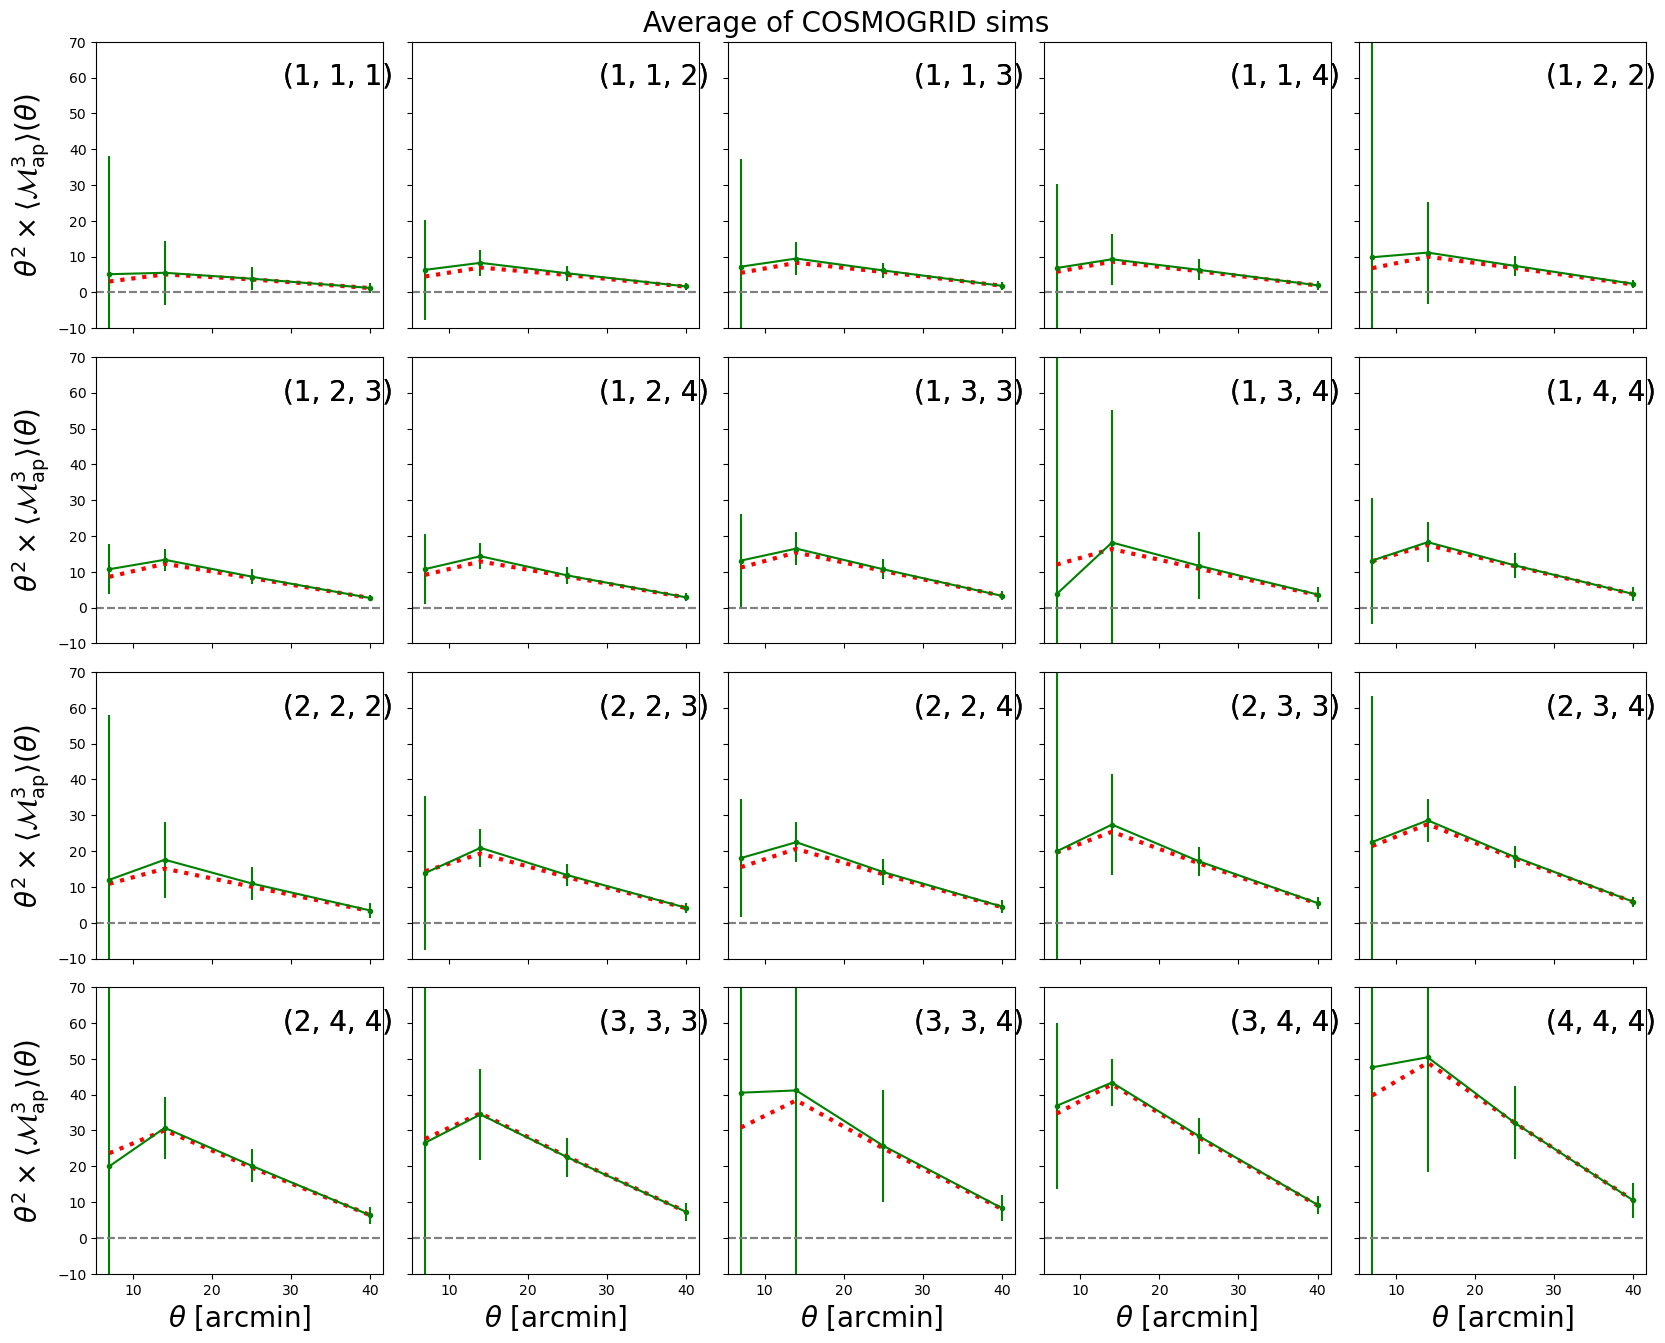

In [8]:
line_args = dict(color='g', ls='-')
fig, axes = thpt_all.plot2d(4, 5, figsize=(20, 16), title='Average of COSMOGRID sims', **line_args)
#line_args2 = dict(color='C0', lw=3, ls=':')
#fig, axes = thpt_theo.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args2)
line_args2 = dict(color='r', lw=3, ls=':')
fig, axes = thpt_bf_map3_all.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args2)
#plt.savefig("../plots/Map3_average_of_cosmogrid_sims.png")

In [25]:
from astropy.io import fits
twopt1_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim1-BESTFIT.fits')
twopt2_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim2-BESTFIT.fits')
twopt3_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sim3-BESTFIT.fits')
twopt_all_file = fits.open('../data/dv/sim_2pt-NLA-some-sims-sims_all-BESTFIT.fits')
twopt_all_2ptbf = fits.open('../data/dv/sim_2pt-NLA-some-sims-2pt-sims_all-BESTFIT.fits')

In [11]:
twopt1_data = fits.open('../data/dv/meas_2pt-sim1-cosmogrid.fits')
twopt2_data = fits.open('../data/dv/meas_2pt-sim2-cosmogrid.fits')
twopt3_data = fits.open('../data/dv/meas_2pt-sim3-cosmogrid.fits')
twopt_all_data = fits.open('../data/dv/meas_2pt-ave-cosmogrid_weighted.fits')

In [12]:
def extract_2pt(fitsfile):
    
    xip = fitsfile[2].data
    xim = fitsfile[3].data
    
    out = np.zeros(400)
    for i in range(200):
        out[i] = fitsfile[2].data[i][3]
        out[i+200] = fitsfile[3].data[i][3]
        
    return(out)

In [13]:
def transform_data(datav):
    transf_moped = np.loadtxt('../data/moped/moped-moped-compress-2pt.txt')
    transformed_data = np.dot(transf_moped.T, datav)
    return(transformed_data)

def transform_cov(covm):
    transf_moped = np.loadtxt('../data/moped/moped-moped-compress-2pt.txt')
    newtransf = np.zeros(shape=(307,96))
    print(np.shape(newtransf[:227,:][:,:16]))
    newtransf[:227,:][:,:16] = transf_moped
    newtransf[227:,:][:,16:] = np.eye(80)
    transformed_cov = np.dot(newtransf.T, np.dot(covm, newtransf))
    return(transformed_cov)

In [14]:
scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])

In [15]:
scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))

In [16]:
scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))

In [17]:
def scale_cut_2pt(vector):
    scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])
    scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))
    scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))
    return (np.delete(vector, scale_cuts_all))

In [18]:
def scale_cut_2pt_cov(matrix):
    scale_cut_indices_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])
    scale_cut_indices_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))
    scale_cuts_all = np.concatenate((scale_cut_indices_xip, scale_cut_indices_xim))
    matrix = np.delete(matrix, scale_cuts_all, axis=0)
    matrix = np.delete(matrix, scale_cuts_all, axis=1)
    return (matrix)

In [19]:
from astropy.io import fits
to_cov = fits.open("../data/covariance/cov_xip_xim_map3.fits")
cov_all_nocut = to_cov[1].data
cov_all = transform_cov(scale_cut_2pt_cov(cov_all_nocut))

(227, 16)


In [26]:
twpt1 = transform_data(scale_cut_2pt(extract_2pt(twopt1_data)))
twpt2 = transform_data(scale_cut_2pt(extract_2pt(twopt2_data)))
twpt3 = transform_data(scale_cut_2pt(extract_2pt(twopt3_data)))
twpt_all = transform_data(scale_cut_2pt(extract_2pt(twopt_all_data)))

twpt_bf_sim1 = transform_data(scale_cut_2pt(extract_2pt(twopt1_file)))
twpt_bf_sim2 = transform_data(scale_cut_2pt(extract_2pt(twopt2_file)))
twpt_bf_sim3 = transform_data(scale_cut_2pt(extract_2pt(twopt3_file)))
twpt_bf_all = transform_data(scale_cut_2pt(extract_2pt(twopt_all_file)))

twpt_bf_only = transform_data(scale_cut_2pt(extract_2pt(twopt_all_2ptbf)))

In [21]:
dados1 = np.concatenate((twpt1,thpt1.get_signal()))
dados2 = np.concatenate((twpt2,thpt2.get_signal()))
dados3 = np.concatenate((twpt3,thpt3.get_signal()))
dados_all = np.concatenate((twpt_all,thpt_all.get_signal()))

teoria1 = np.concatenate((twpt_bf_sim1,thpt_bf_sim1.get_signal()))
teoria2 = np.concatenate((twpt_bf_sim2,thpt_bf_sim2.get_signal()))
teoria3 = np.concatenate((twpt_bf_sim3,thpt_bf_sim3.get_signal()))
teoria_all = np.concatenate((twpt_bf_all,thpt_bf_all.get_signal()))

In [22]:
dife1 = dados1 - teoria1
dife2 = dados2 - teoria2
dife3 = dados3 - teoria3
dife_all = dados_all - teoria_all

f = (500-dife1.size-2)/(500-1)
icov_all = np.linalg.inv(cov_all) * f

chi21 = dife1.dot(icov_all).dot(dife1)
dof1  = dife1.size
print('{:.3f}/{}={:.3f}'.format(chi21, dof1, chi21/dof1))

chi22 = dife2.dot(icov_all).dot(dife2)
dof2  = dife2.size
print('{:.3f}/{}={:.3f}'.format(chi22, dof2, chi22/dof2))

chi23 = dife3.dot(icov_all).dot(dife3)
dof3  = dife3.size
print('{:.3f}/{}={:.3f}'.format(chi23, dof3, chi23/dof3))

chi2_all = dife_all.dot(icov_all).dot(dife_all)
dof_all  = dife_all.size
print('{:.3f}/{}={:.3f}'.format(chi2_all, dof_all, chi2_all/dof_all))

79.110/96=0.824
71.417/96=0.744
79.207/96=0.825
2.013/96=0.021


In [23]:
dadosm = thpt_all.get_signal()
teoriam = thpt_bf_map3_all.get_signal()

difem = dadosm - teoriam
cov_allm = to_cov[1].data[400:,:][:,400:]

f = (500-difem.size-2)/(500-1)
icov_allm = np.linalg.inv(cov_allm) * f

chi2m = difem.dot(icov_allm).dot(difem)
dofm  = difem.size
print('{:.3f}/{}={:.3f}'.format(chi2m, dofm, chi2m/dofm))

0.419/80=0.005


In [30]:
dadosx = twpt_all
teoriax = twpt_bf_only

difex = dadosx - teoriax
cov_allx = cov_all[:16,:][:,:16]

f = (500-difex.size-2)/(500-1)
icov_allx = np.linalg.inv(cov_allx) * f

chi2x = difex.dot(icov_allx).dot(difex)
dofx  = difex.size
print('{:.3f}/{}={:.3f}'.format(chi2x, dofx, chi2x/dofx))

1.013/16=0.063


## Testing chi2 values as a function of scale and z

In [ ]:
for Rmin in [7]:
    # 
    data = thpt1.get_signal()
    theo = thpt_bf_sim1.get_signal()
    diff = data - theo
    R    = thpt1.get_t_bin()[0]
    #
    sel  = R>=Rmin
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
for Rmin in [7]:
    # 
    data = thpt2.get_signal()
    theo = thpt_bf_sim2.get_signal()
    diff = data - theo
    R    = thpt1.get_t_bin()[0]
    #
    sel  = R>=Rmin
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
for Rmin in [7]:
    # 
    data = thpt3.get_signal()
    theo = thpt_bf_sim3.get_signal()
    diff = data - theo
    R    = thpt1.get_t_bin()[0]
    #
    sel  = R>=Rmin
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
#old bestfit, new cov
for Rmin in [7,14,25, 40]:
    # 
    data = thpt.get_signal()
    theo = thpt_bf_old.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    R    = thpt.get_t_bin()[0]
    #
    sel  = R>=Rmin
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
for Rmax in [7,14,25, 40]:
    # 
    data = thpt.get_signal()
    theo = thpt_bf.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    R    = thpt.get_t_bin()[0]
    #
    sel  = R<=Rmax
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov) * f
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
for i in range(20):
    # 
    data = thpt.get_signal()
    theo = thpt_bf.get_signal()
    diff = data - theo
    cov  = thpt.get_covariance()
    # print(np.unique(R))
    #
    sel  = np.arange(4*i, 4*(i+1), 1)
    diff = diff[sel]
    cov  = cov[np.ix_(sel, sel)]
    # 
    f = (500-diff.size-2)/(500-1)
    icov = np.linalg.inv(cov)
    chi2 = diff.dot(icov).dot(diff)
    dof  = diff.size
    print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
data = thpt.get_signal()
theo = thpt_bf.get_signal()
diff = data - theo
cov  = thpt.get_covariance()
cov  = np.diag(np.diag(cov)) # Take only diagonal
R    = thpt.get_t_bin()[0]
# 
f = (400-diff.size-2)/(400-1)
icov = np.linalg.inv(cov) * f
chi2 = diff.dot(icov).dot(diff)
dof  = diff.size
print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))

In [ ]:
data = thpt.get_signal()
theo = thpt_bf.get_signal()
diff = data - theo
# cov  = thpt.get_covariance()
cov = np.loadtxt('../data/meas4k/cov_2pcf_map3_n380_noise0.dat')[400:, 400:]
R    = thpt.get_t_bin()[0]
# 
f = (400-diff.size-2)/(400-1)
icov = np.linalg.inv(cov) * f
chi2 = diff.dot(icov).dot(diff)
dof  = diff.size
print('{:.3f}/{}={:.3f}'.format(chi2, dof, chi2/dof))